In [134]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
df = pd.read_csv("./Banking_churn_prediction.csv") 
df.head(10)

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03
5,7,1923,42,Female,0.0,self_employed,1096.0,2,1666,15202.20,...,15211.29,13798.82,0.36,0.36,857.50,286.07,15719.44,15349.75,0,2019-11-01
6,8,2048,72,Male,0.0,retired,1020.0,1,1,7006.93,...,7859.74,11232.37,0.64,0.64,1299.64,439.26,7076.06,7755.98,0,2019-09-24
7,9,2009,46,Male,0.0,self_employed,623.0,2,317,10096.58,...,6511.82,16314.17,0.27,0.27,443.13,5688.44,8563.84,5317.04,0,2019-07-12
8,10,2053,31,Male,0.0,salaried,1096.0,2,4110,1355.86,...,1702.44,1126.13,714.51,121.09,714.51,359.44,1183.45,1857.42,0,2019-12-12
9,11,2295,40,Male,3.0,self_employed,1020.0,2,38,4957.95,...,2168.53,1864.33,6912.29,4206.13,1887.30,1348.85,1823.16,2416.69,0,2019-12-31


In [130]:
# Step 3: Basic overview
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.info())
print(df.describe(include='all'))

Shape: (28382, 21)
Columns: Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn',
       'last_transaction'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents

In [131]:
# Step 4: Missing values check
print(df.isnull().sum())

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
dtype: int64


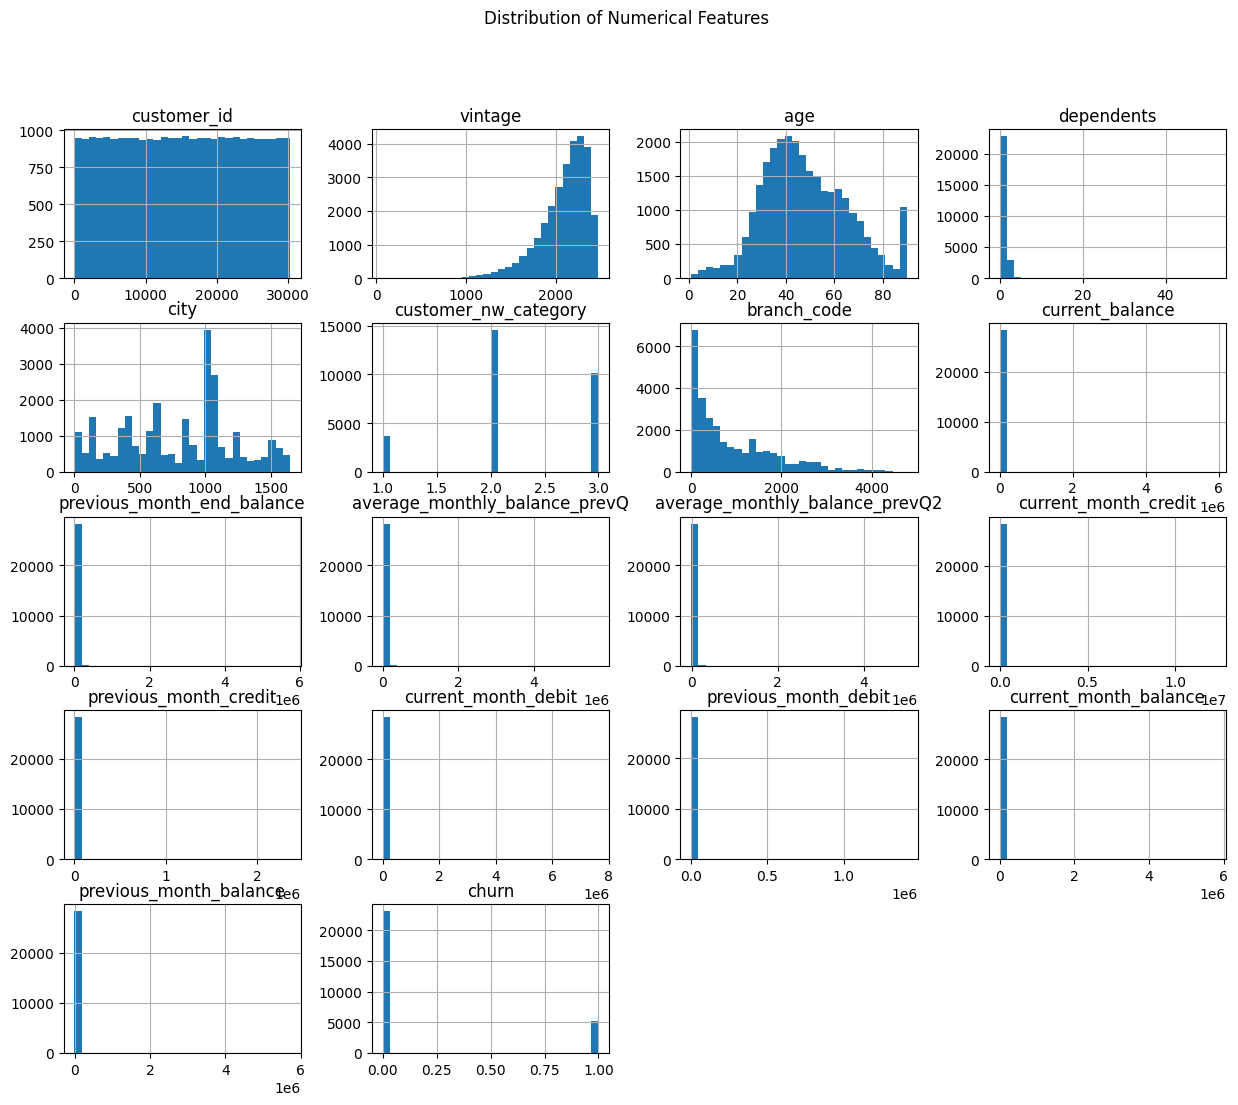

In [132]:
# Step 5: Univariate Analysis
# Numerical distributions
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [ ]:
#missing_percent value
missing_percent = df.isnull().mean() * 100
print(missing_percent)


customer_id                       0.000000
vintage                           0.000000
age                               0.000000
gender                            1.849764
dependents                        8.678035
occupation                        0.281869
city                              2.829258
customer_nw_category              0.000000
branch_code                       0.000000
current_balance                   0.000000
previous_month_end_balance        0.000000
average_monthly_balance_prevQ     0.000000
average_monthly_balance_prevQ2    0.000000
current_month_credit              0.000000
previous_month_credit             0.000000
current_month_debit               0.000000
previous_month_debit              0.000000
current_month_balance             0.000000
previous_month_balance            0.000000
churn                             0.000000
last_transaction                  0.000000
dtype: float64


In [136]:
df['dependents'].value_counts()

dependents
0.0     23898
2.0      2150
1.0      1395
3.0       701
4.0       179
5.0        41
6.0         8
7.0         3
9.0         1
52.0        1
36.0        1
50.0        1
8.0         1
25.0        1
32.0        1
Name: count, dtype: int64

In [ ]:
# Step: Handle Missing Values

# Special handling examples
df.fillna({'dependents': 0}, inplace=True) # assume missing means no dependents
df.fillna({'occupation': "Unknown"}, inplace=True)  # assume missing means unknown
mean_gender = df['gender'].mode()[0]
df.fillna({'gender': mean_gender}, inplace=True)

# Numerical columns: fill with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)




In [159]:
missing_percent = df.isnull().mean() * 100
print(missing_percent)

customer_id                       0.0
vintage                           0.0
age                               0.0
gender                            0.0
dependents                        0.0
occupation                        0.0
city                              0.0
customer_nw_category              0.0
branch_code                       0.0
current_balance                   0.0
previous_month_end_balance        0.0
average_monthly_balance_prevQ     0.0
average_monthly_balance_prevQ2    0.0
current_month_credit              0.0
previous_month_credit             0.0
current_month_debit               0.0
previous_month_debit              0.0
current_month_balance             0.0
previous_month_balance            0.0
churn                             0.0
last_transaction                  0.0
dtype: float64


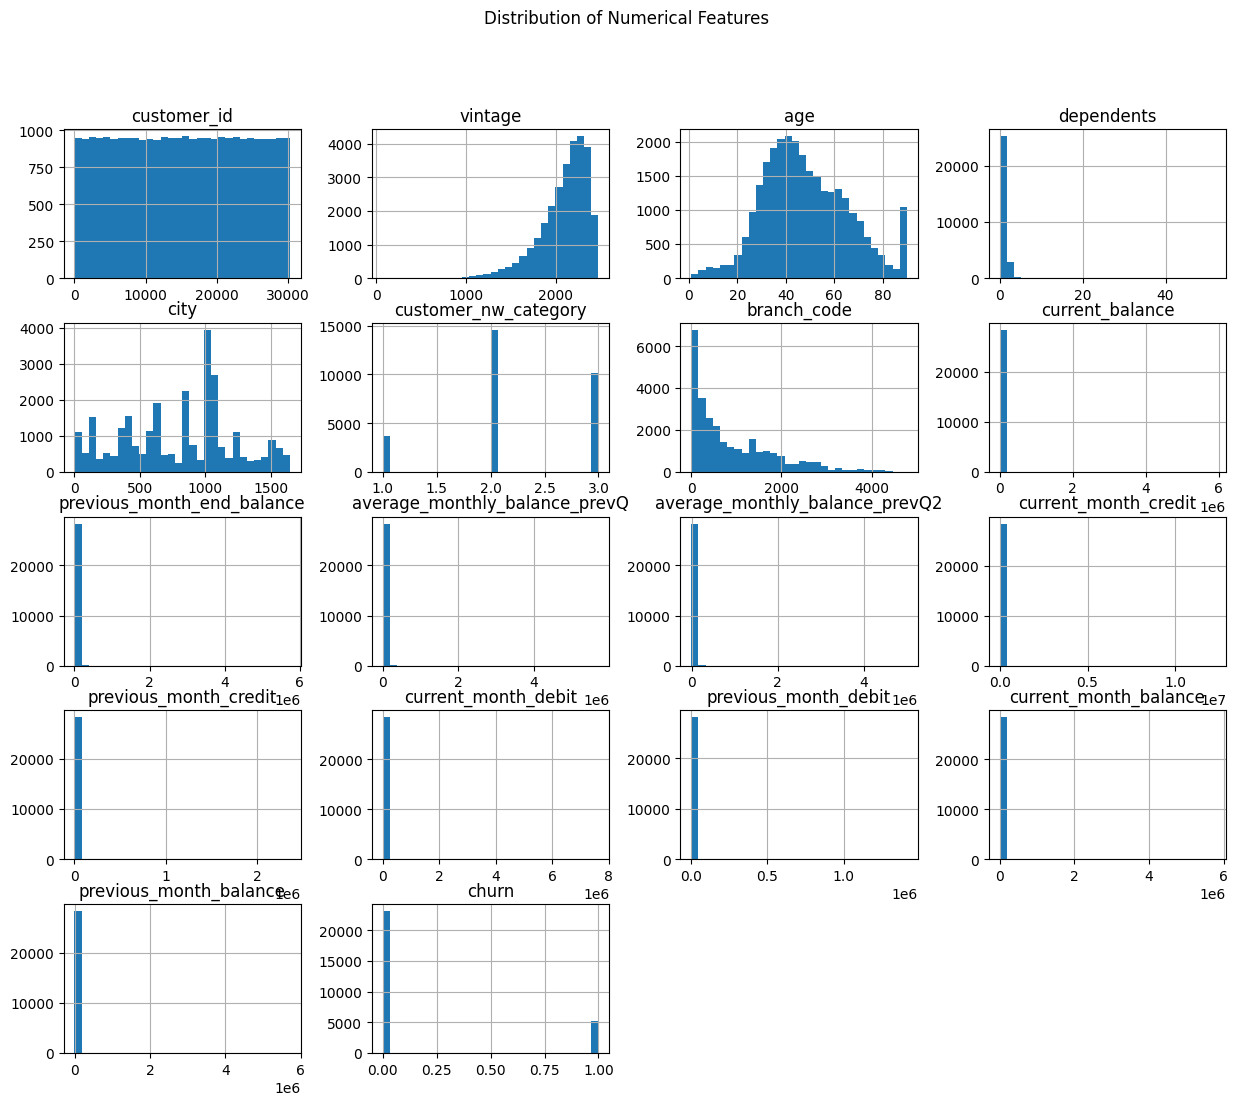

In [160]:
# Step 5: Univariate Analysis after filling null values
# Numerical distributions
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

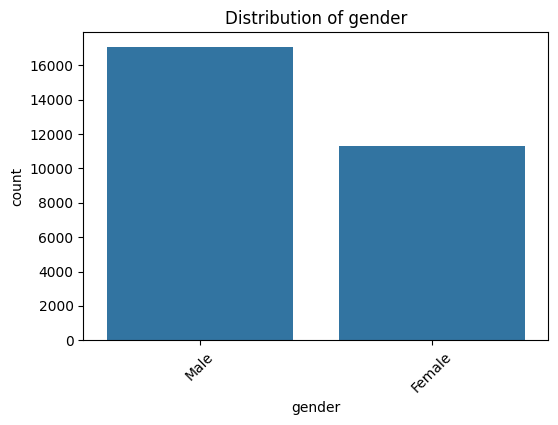

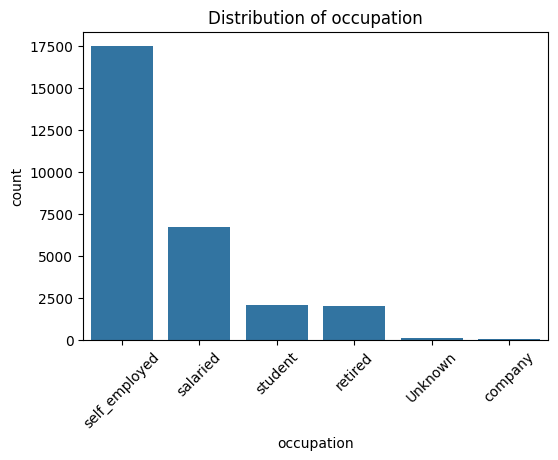

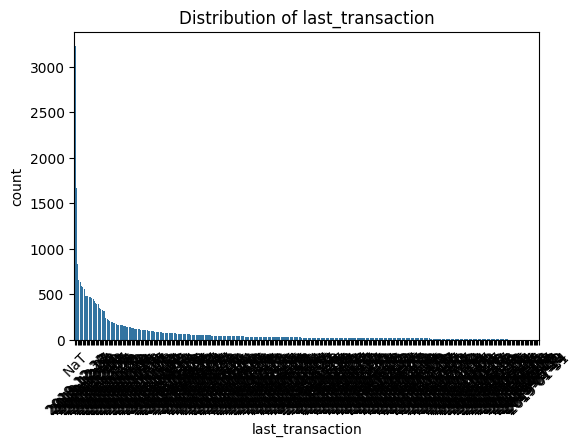

In [161]:
# Categorical distributions
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

Overall churn rate: 0.18532872947642873


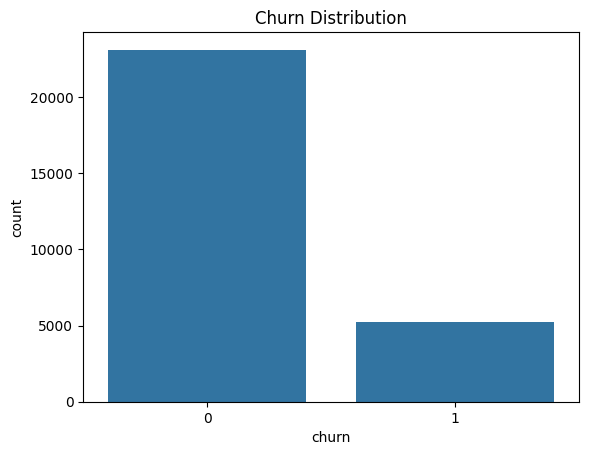

In [162]:
# Step 6: Churn Rate
churn_rate = df['churn'].mean()
print("Overall churn rate:", churn_rate)

sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

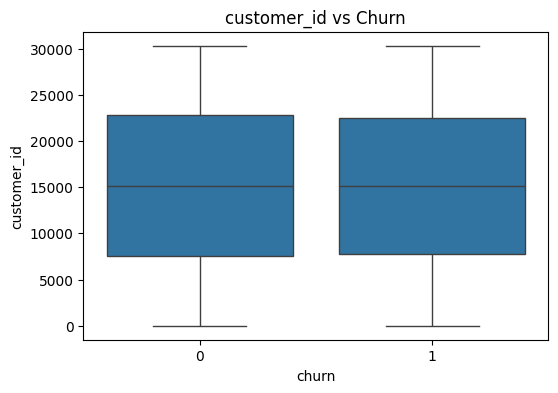

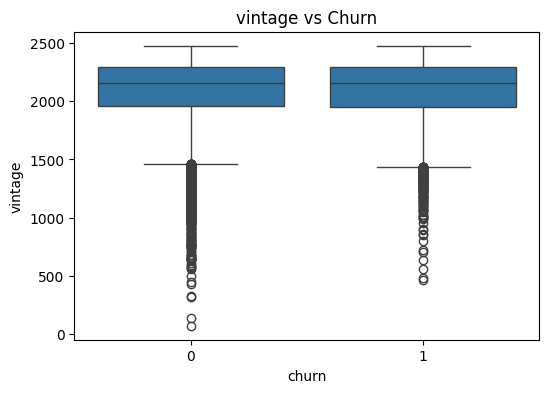

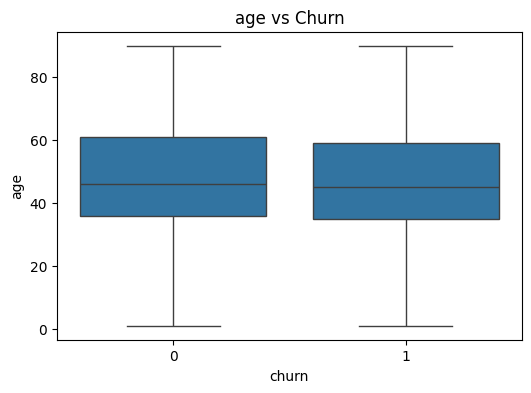

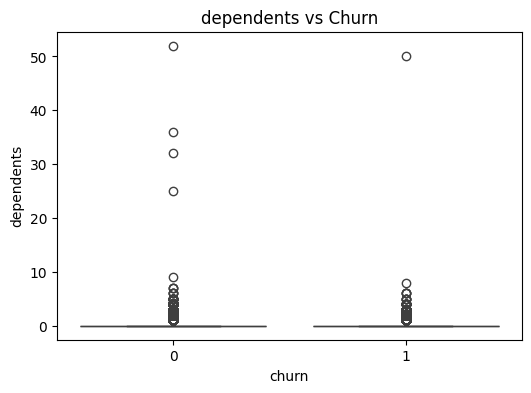

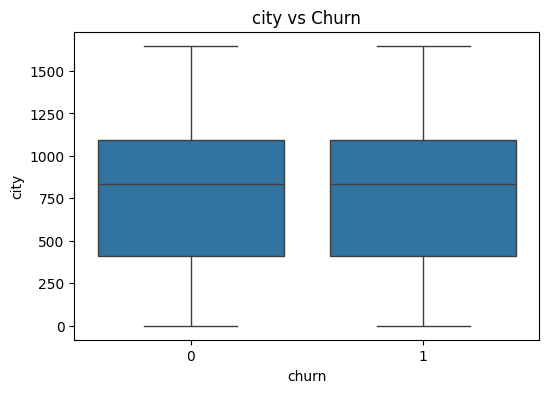

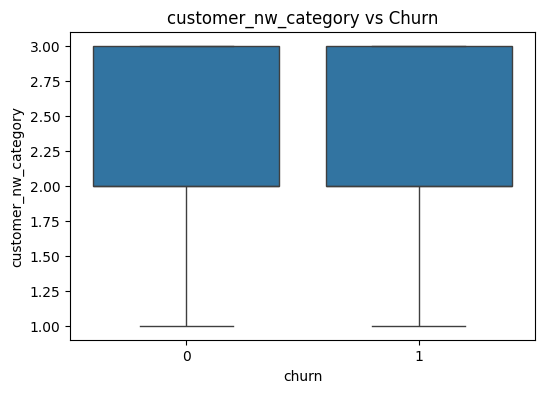

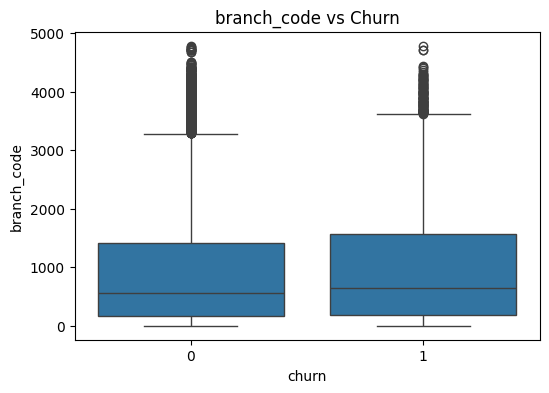

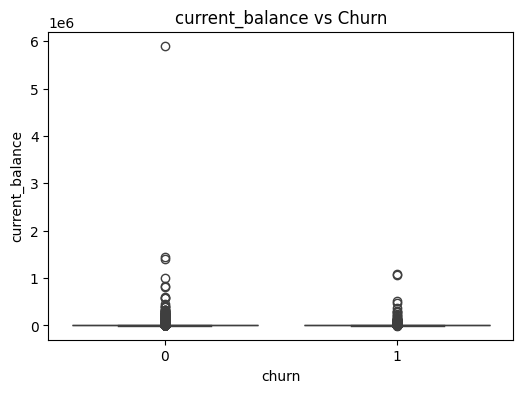

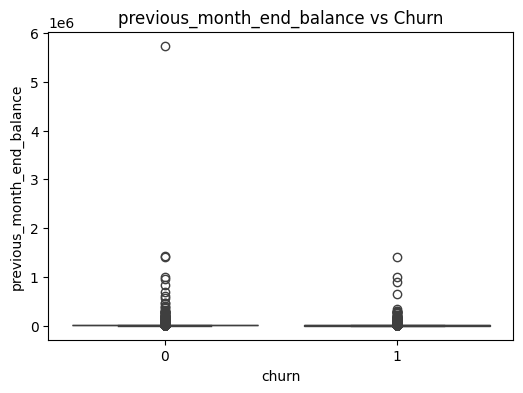

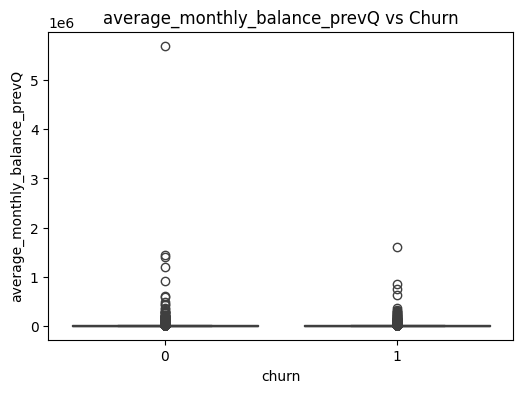

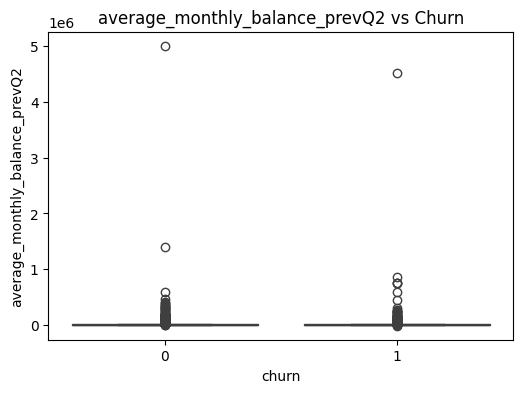

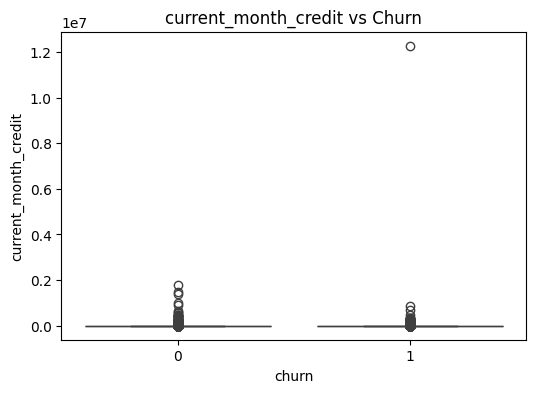

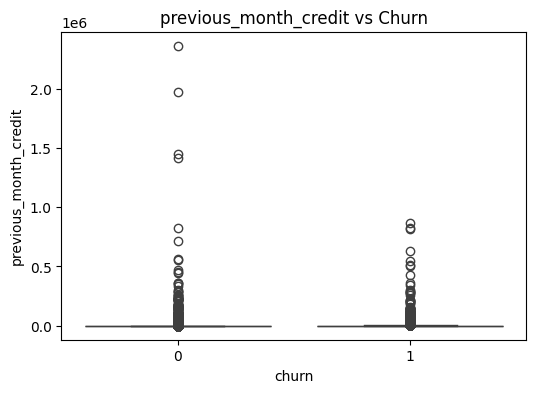

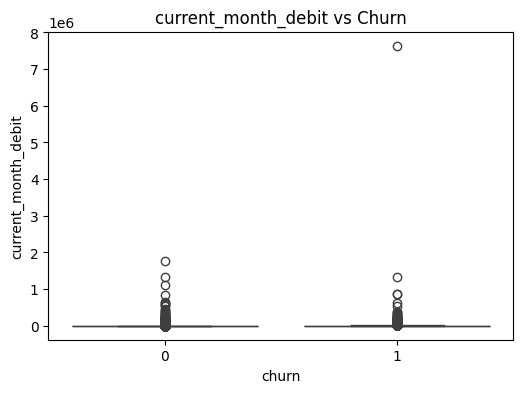

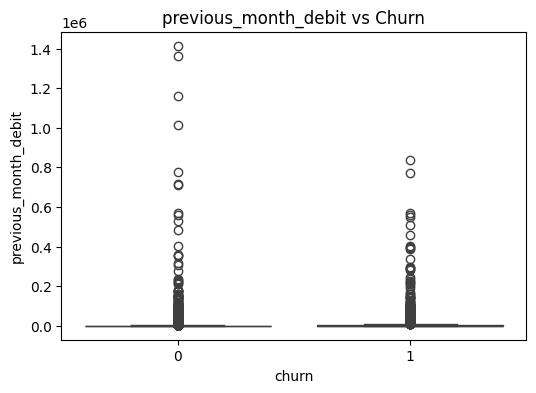

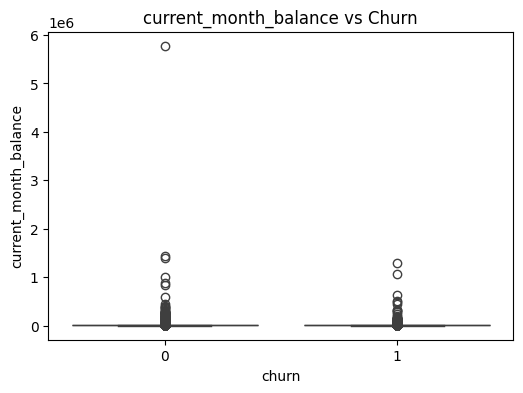

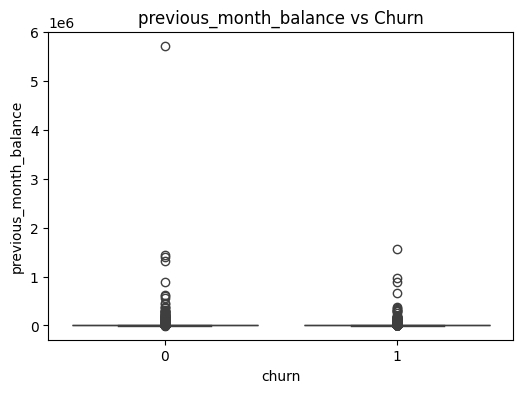

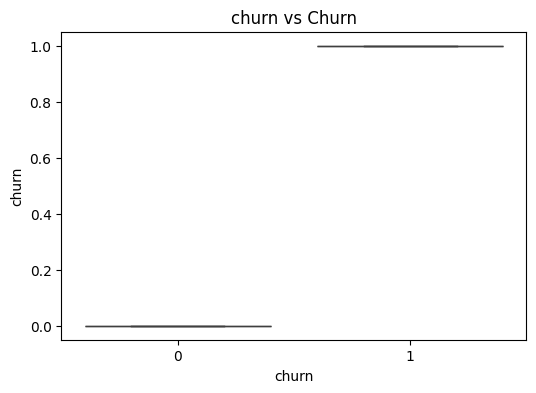

In [163]:
# Step 7: Bivariate Analysis
# Numerical vs churn
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()



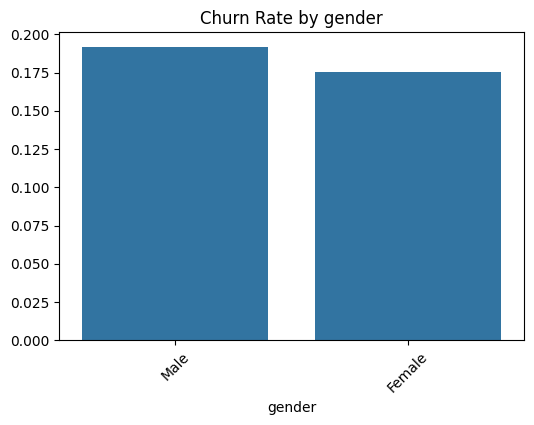

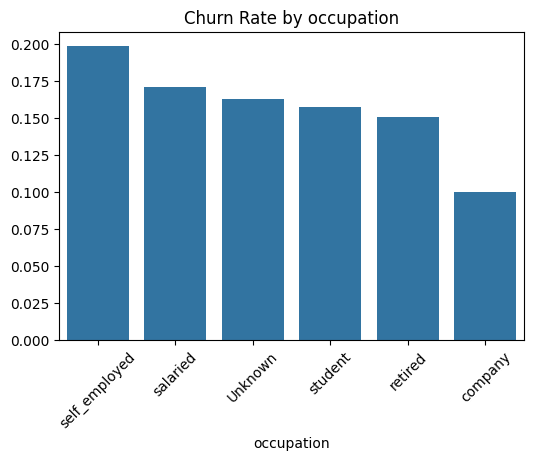

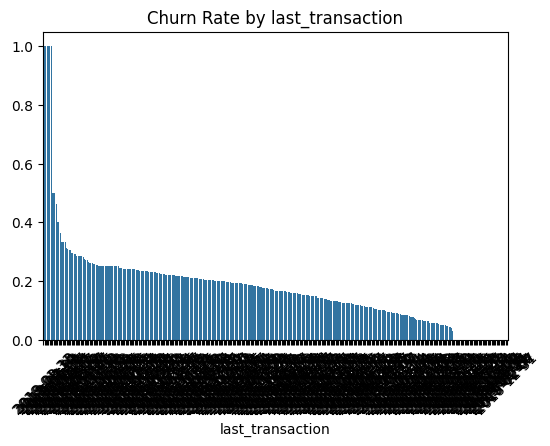

In [164]:
# Categorical vs churn
for col in cat_cols:
    plt.figure(figsize=(6,4))
    churn_by_cat = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values)
    plt.title(f"Churn Rate by {col}")
    plt.xticks(rotation=45)
    plt.show()

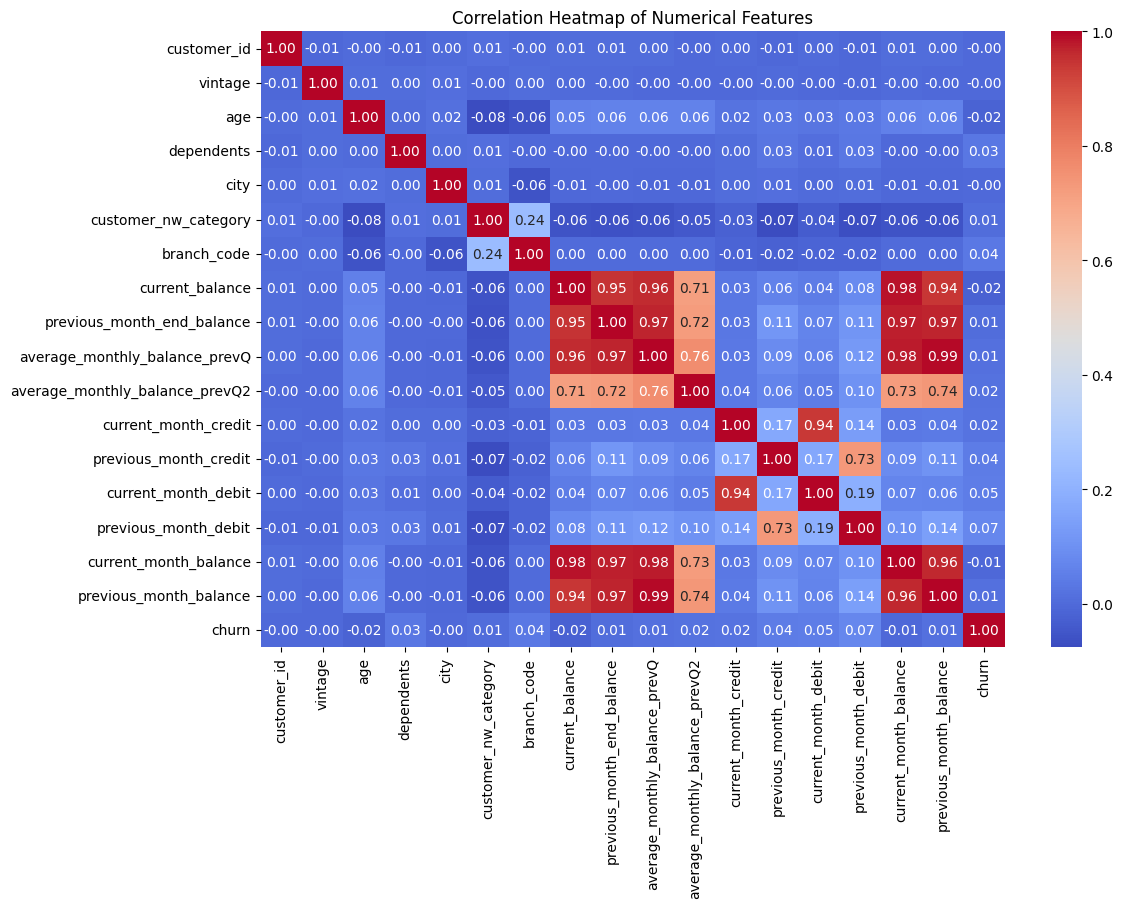

In [165]:
# Step 8: Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

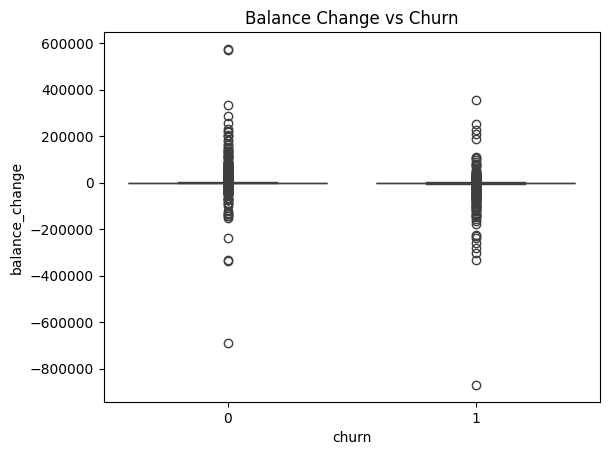

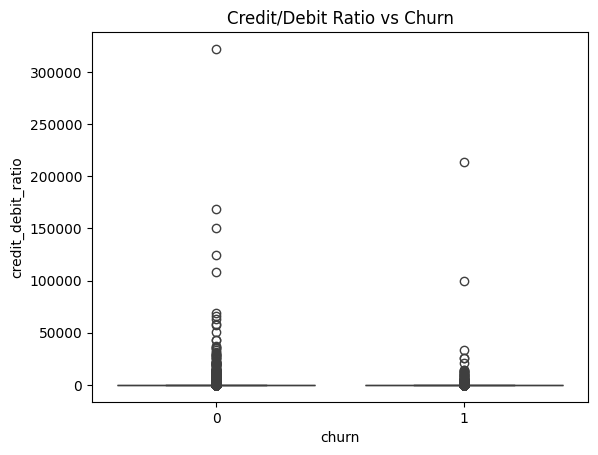

In [166]:
# Step 9: Derived Features (examples)
df['balance_change'] = df['current_balance'] - df['previous_month_end_balance']
df['credit_debit_ratio'] = df['current_month_credit'] / (df['current_month_debit']+1)

sns.boxplot(x='churn', y='balance_change', data=df)
plt.title("Balance Change vs Churn")
plt.show()

sns.boxplot(x='churn', y='credit_debit_ratio', data=df)
plt.title("Credit/Debit Ratio vs Churn")
plt.show()
